In [9]:
import oncophylo as op
import numpy as np
import pandas as pd
import anndata as ad
import os, sys
import matplotlib.pyplot as plt

In [10]:
path = os.path.join(os.getcwd(), "data", "AML")

In [16]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

def plot_coverage_distributions(
    data,
    sample_names=None,
    cna_regions=None,
    plot_all_regions=True,
    bins=40,
    density=True,   # now interpreted as "percent mode"
    ncols=4,
    save_path=None,
):
    """
    Plot normalized coverage distributions for genomic regions.

    If density=True:
        y-axis shows percent of cells per bin (interpretable as frequency)
    """

    if sample_names is None:
        sample_names = [f"Sample {i+1}" for i in range(len(data))]

    cna_regions = set() if cna_regions is None else set(cna_regions)

    for sample_name, (_, sample_regions_df) in zip(sample_names, data):

        # ----------------------------
        # Normalize coverage per cell
        # ----------------------------
        normalized = sample_regions_df.T.div(
            sample_regions_df.T.sum(axis=1), axis=0
        )

        # ----------------------------
        # Select regions
        # ----------------------------
        if plot_all_regions:
            regions = list(normalized.columns)
        else:
            regions = [
                r for r in normalized.columns
                if r.split("_")[1] in cna_regions
            ]

        if len(regions) == 0:
            print(f"{sample_name}: no regions selected.")
            continue

        nrows = math.ceil(len(regions) / ncols)

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(4 * ncols, 3 * nrows),
            constrained_layout=True,
        )

        # ----------------------------
        # Robust flattening of axes
        # ----------------------------
        if len(regions) == 1:
            axes = [axes]
        else:
            axes = axes.ravel().tolist()

        # ----------------------------
        # Plot
        # ----------------------------
        for ax, region in zip(axes, regions):

            region_name = region.split("_")[1] if "_" in region else region
            chrom = region.split("_")[0] if "_" in region else region
            
            is_cna = region_name in cna_regions
            print(f"{region}\n-------\nMean:{normalized[region].mean()}\
                                     \nMedian: {np.median(normalized[region])}\
                                     \nSkew: {normalized[region].skew()}")
            sns.histplot(
                normalized[region],
                bins=bins,
                stat="probability",   # <-- KEY: fraction of cells
                color="tab:red" if is_cna else "tab:blue",
                edgecolor="black",
                linewidth=0,
                ax=ax,
            )

            # Convert y-axis to percent
            ax.yaxis.set_major_formatter(
                plt.FuncFormatter(lambda y, _: f"{y*100:.0f}%")
            )

            ax.set_title(f"{region_name} (chr{chrom})")

            ax.set_xlabel("Normalized coverage")
            ax.set_ylabel("Percentage of cells")

        # ----------------------------
        # Hide unused panels
        # ----------------------------
        for ax in axes[len(regions):]:
            ax.set_visible(False)

        fig.suptitle(sample_name, fontsize=14)

        # ----------------------------
        # Save or show
        # ----------------------------
        if save_path is None:
            plt.show()
        else:
            fig.savefig(save_path, dpi=300, bbox_inches="tight")
            plt.close(fig)

## AML-39

In [17]:
sample1 = "AML-39-001"

sample_names = [sample1]

sample1_variants_df = pd.read_csv(os.path.join(path, f"{sample1}_variants.csv"), header=0, index_col=0)
sample1_regions_df = pd.read_csv(os.path.join(path, f"{sample1}_regions.csv"), header=None, index_col=0)

data = [(sample1_variants_df, sample1_regions_df)]

7_EZH2
-------
Mean:0.036892703105004046                                     
Median: 0.03493837894533461                                     
Skew: 0.3462286565802478


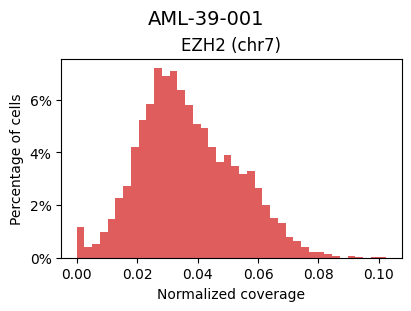

In [18]:
plot_coverage_distributions(data, sample_names, cna_regions=["EZH2"], plot_all_regions=False, ncols=1)#, save_path=os.path.join(os.getcwd(), "AML39_region_coverage.svg"))

## AML-83

In [19]:
sample2 = "AML-83-002"

sample_names = [sample2]

sample2_variants_df = pd.read_csv(os.path.join(path, f"{sample2}_variants.csv"), header=0, index_col=0)
sample2_regions_df = pd.read_csv(os.path.join(path, f"{sample2}_regions.csv"), header=None, index_col=0)

data = [(sample2_variants_df, sample2_regions_df)]

8_RAD21
-------
Mean:0.022892554376245912                                     
Median: 0.022807230377289822                                     
Skew: 1.0295347679974027
8_MYC
-------
Mean:0.015253821651355944                                     
Median: 0.01480643981964172                                     
Skew: 0.5585735757662376


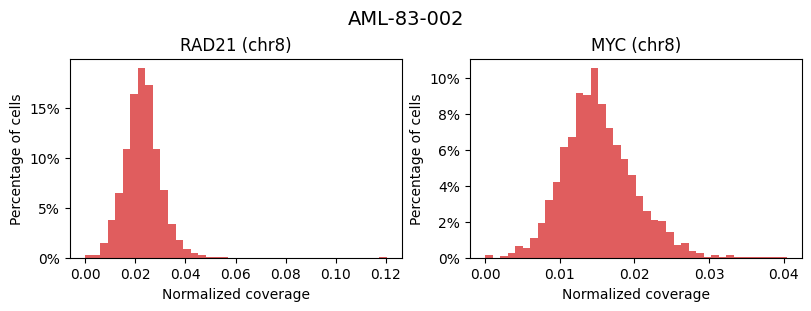

In [20]:
plot_coverage_distributions(data, sample_names, cna_regions=["RAD21", "MYC"], plot_all_regions=False, ncols=2)#, save_path=os.path.join(os.getcwd(), "AML83_region_coverage.svg"))

## AML-99

In [21]:
sample1 = "AML-99-001"

sample_names = [sample1]

sample1_variants_df = pd.read_csv(os.path.join(path, f"{sample1}_variants.csv"), header=0, index_col=0)
sample1_regions_df = pd.read_csv(os.path.join(path, f"{sample1}_regions.csv"), header=None, index_col=0)


data = [(sample1_variants_df, sample1_regions_df)]

In [22]:
plot_coverage_distributions(data, sample_names, cna_regions=["RAD21", "MYC"], ncols=2, plot_all_regions=False, save_path=os.path.join(os.getcwd(), "AML99_region_coverage.svg"))

8_RAD21
-------
Mean:0.018317573815553184                                     
Median: 0.018068405038181006                                     
Skew: 0.3048796973803339
8_MYC
-------
Mean:0.01886226845488919                                     
Median: 0.01847242821630273                                     
Skew: 0.46113537211323746


In [138]:
sample1_variants_df

,POS,REF,ALT,REGION,NAME,FREQ,0,1,2,3,...,4402,4403,4404,4405,4406,4407,4408,4409,4410,4411
CHR,,,,,,,,,,,,,,,,,,,,,
1,36932248,G,A,CSF3R,CSF3R p.Q768*,0.000000,41:0:0,145:0:0,61:0:0,105:0:0,...,69:0:0,179:2:0,80:1:0,122:0:0,75:0:0,58:0:0,50:0:0,149:0:0,143:0:0,50:0:0
2,25457242,C,T,DNMT3A,DNMT3A p.R882H,0.000000,3:39:2,61:107:1,4:0:3,22:6:1,...,16:0:0,21:65:1,42:4:0,12:42:1,23:17:1,43:57:1,35:7:3,21:10:1,59:92:1,9:14:1
8,117864217,A,G,RAD21,RAD21 silent,0.133187,120:55:1,92:119:1,13:71:1,34:113:1,...,77:82:1,128:194:1,99:86:1,29:207:2,76:95:1,43:98:1,71:95:1,93:205:1,121:138:1,187:187:1
15,90631934,C,T,IDH2,IDH2 p.R140Q,0.000000,24:18:1,21:33:1,2:0:3,67:184:1,...,30:2:0,26:55:1,244:14:0,58:102:1,78:21:1,8:26:1,0:7:2,129:74:1,64:228:1,22:73:1
21,36252877,C,T,RUNX1,RUNX1 p.R162K,0.000000,0:16:2,0:170:2,0:177:2,0:128:2,...,0:0:3,0:132:2,0:0:3,0:5:3,30:0:0,0:81:2,0:29:2,0:58:2,0:21:2,0:10:2
